# First Run of a AutoRegressive-LSTM on the App **MASSA**
 
**Paramaters**
The objective of this first run is to do it as simple as possible, to control if the set up is correct and that the code works fine.
- the config file:  *ARLSTM_v0.yml*
- basins folder:    *../data/basins.txt* (only massa)
- dataset file:     *../../../data/Massa/massa.csv*

For now, we only use 2 dynamical forcing variables:
1. precipitation at the station Bruchji: prec_bruchji (column CV)
2. temperature at the station Binn: temp_binn (column Y)

**NOTE:** no controle of the quality of the dataset has been made for now.

### Imports

In [1]:
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
import torch

from neuralhydrology.evaluation import metrics
from neuralhydrology.nh_run import start_run, eval_run
from neuralhydrology.datasetzoo import register_dataset

### Adding our Dataset | Metrics | Models

In [2]:
from custom.dataset.swisshourly import SwissHourly
register_dataset("swisshourly", SwissHourly)  # key used in your YAML
from neuralhydrology.utils.config import Config

# Custom functions plot_training_curves
from custom.functions.Plot import plot_hydrograph, plot_training_curves, plot_validation_metrics
from custom.functions.utils_fla import parse_neuralhydrology_log


---

In [ ]:
configPath = Path("1h_v3.yml")

runFile = "1h_v3_0810_155627"

cfg = Config(configPath)
TRAIN = False
Evaluation_TEST = False


### Training

In [ ]:
if TRAIN:
    print(" Starting the training  ")
    # by default we assume that you have at least one cuda-capable nvidia gpu or macos with metal support
    if torch.cuda.is_available() or torch.backends.mps.is_available():
        print("Using GPU")
        start_run(config_file=Path(configPath))
    # fall back to cpu-only mode
    else:
        print("Using CPU")
        start_run(config_file=Path(configPath), gpu=-1)
    print("==================================")
    print("  Training ended successfully !   ")
    print("==================================")
else: print(" Training step skipped !")

 Starting the training  
Using GPU
2025-10-10 11:05:23,184: Logging to c:\Users\Kohler\Documents\NeuralHydrology_FK\neuralhydrology\test_Fla\Massa\ARLSM_simple\runs\1h_v3_1010_110523\output.log initialized.
2025-10-10 11:05:23,185: ### Folder structure created at c:\Users\Kohler\Documents\NeuralHydrology_FK\neuralhydrology\test_Fla\Massa\ARLSM_simple\runs\1h_v3_1010_110523
2025-10-10 11:05:23,185: ### Run configurations for 1h_v3
2025-10-10 11:05:23,186: experiment_name: 1h_v3
2025-10-10 11:05:23,186: base_run_dir: runs
2025-10-10 11:05:23,186: train_dir: c:\Users\Kohler\Documents\NeuralHydrology_FK\neuralhydrology\test_Fla\Massa\ARLSM_simple\runs\1h_v3_1010_110523\train_data
2025-10-10 11:05:23,187: img_log_dir: c:\Users\Kohler\Documents\NeuralHydrology_FK\neuralhydrology\test_Fla\Massa\ARLSM_simple\runs\1h_v3_1010_110523\img_log
2025-10-10 11:05:23,188: seed: 42
2025-10-10 11:05:23,188: device: cuda:0
2025-10-10 11:05:23,189: num_workers: 16
2025-10-10 11:05:23,190: data_dir: ..\..\.

✅ Parsed 34 training epochs and 34 validation evaluations.
Plotting the losses and metrics throughout the training process: 


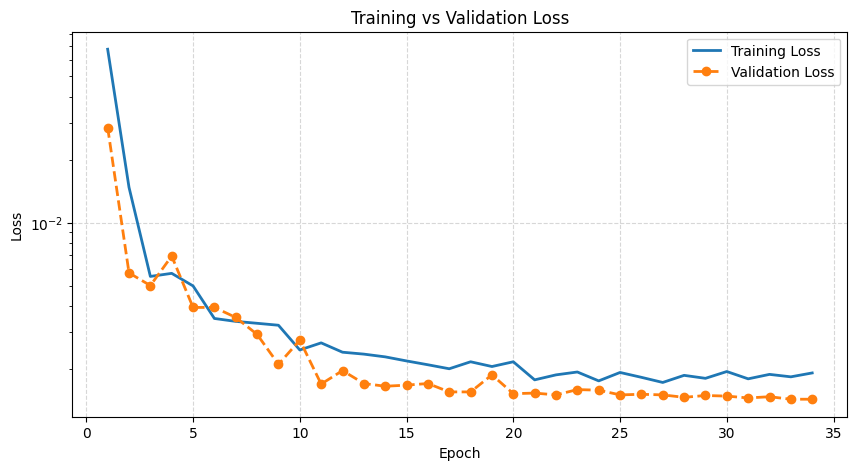

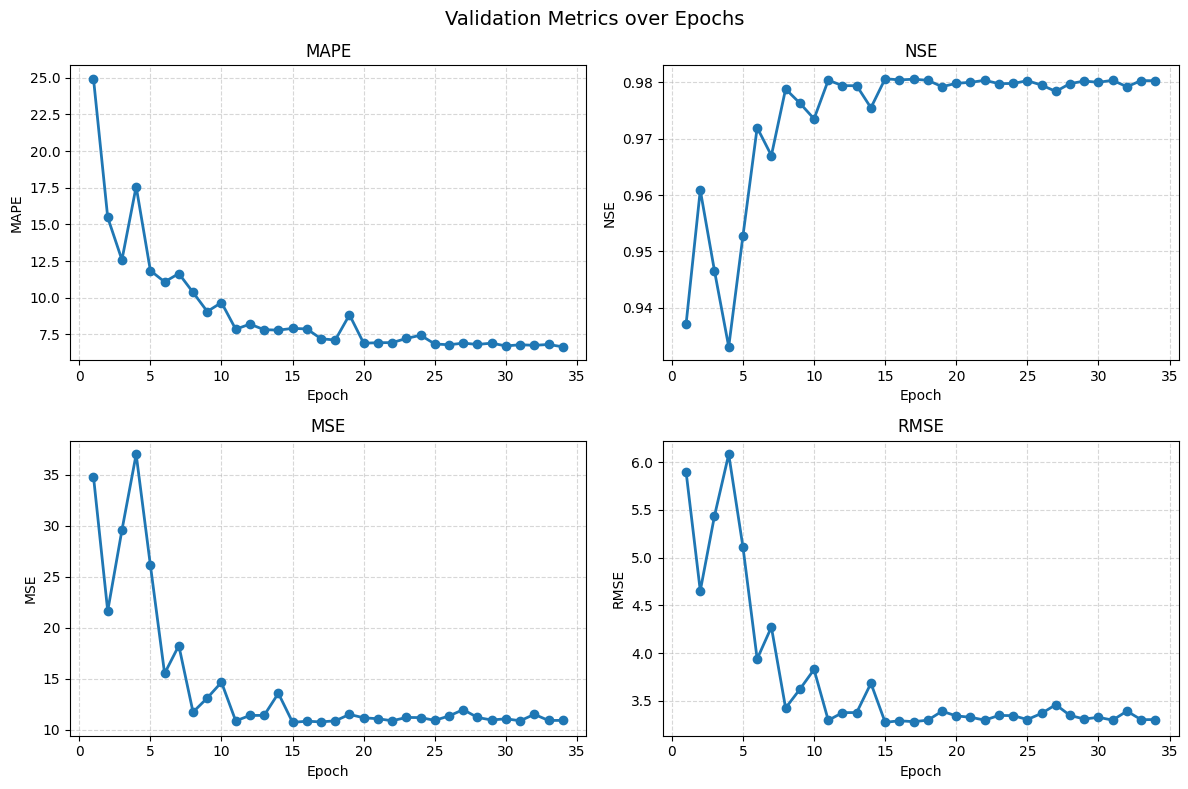

In [ ]:
# Path to your output.log file
log_path = Path(f"{cfg.base_run_dir}/{runFile}/output.log")
train_df, val_df = parse_neuralhydrology_log(log_path)

print("Plotting the losses and metrics throughout the training process: ")
plot_training_curves(train_df, val_df)
plot_validation_metrics(val_df)


---

## Evaluation on the TEST Dataset
The run directory that needs to be specified for evaluation is printed in the output log above. Since the folder name is created dynamically (including the date and time of the start of the run) you will need to change the `run_dir` argument according to your local directory name. By default, it will use the same device as during the training process.

In [ ]:
run_dir = Path(f"{cfg.base_run_dir}/{runFile}")

if Evaluation_TEST:
    print(" Starting the EVALUATION on the test period:  ")
    eval_run(run_dir=run_dir, period="test")
    print("==================================")
    print("  TEST ended successfully !   ")
    print("==================================")
else: print(" Testing process skipped !")

 Testing process skipped !


### Load and inspect model predictions
Next, we load the results file and compare the model predictions with observations. The results file is always a pickled dictionary with one key per basin (even for a single basin). The next-lower dictionary level is the temporal resolution of the predictions. In this case, we trained a model only on daily data ('1D'). Within the temporal resolution, the next-lower dictionary level are `xr`(an xarray Dataset that contains observations and predictions), as well as one key for each metric that was specified in the config file.

In [ ]:
testPath = Path(run_dir / "test" / f"model_epoch0{cfg.epochs}" / "test_results.p")
with open(testPath, "rb") as fp:
    results = pickle.load(fp)

# results.keys()
results['massa']['1h']

{'xr': <xarray.Dataset> Size: 164kB
 Dimensions:         (date: 10224, time_step: 1)
 Coordinates:
   * date            (date) datetime64[ns] 82kB 2024-04-01 ... 2025-05-31T23:0...
   * time_step       (time_step) int64 8B 0
 Data variables:
     streamflow_obs  (date, time_step) float32 41kB 1.155 1.146 ... 27.32 26.4
     streamflow_sim  (date, time_step) float32 41kB 1.626 1.639 ... 30.9 30.22,
 'MAPE': 6.399970531463623,
 'NSE': 0.9673395156860352,
 'MSE': 19.34478187561035,
 'RMSE': 4.398270327709559}

The data variables in the xarray Dataset are named according to the name of the target variables, with suffix `_obs` for the observations and suffix `_sim` for the simulations.

In [ ]:
# results['massa']['1h']['xr']['streamflow_obs'][0]

Let's plot the model predictions vs. the observations

In [ ]:
qobs=results['massa']['1h']['xr']['streamflow_obs']
qsim=results['massa']['1h']['xr']['streamflow_sim']
plot_hydrograph(
    qobs=qobs,
    qsim=qsim,
    results=results,
    basin='massa',
    freq='1h',
    plot_peaks=False  # turn on high-flow markers
)

Next, we are going to compute all metrics that are implemented in the NeuralHydrology package. You will find additional hydrological signatures implemented in `neuralhydrology.evaluation.signatures`.

In [ ]:
values = metrics.calculate_all_metrics(qobs.isel(time_step=-1), qsim.isel(time_step=-1))
for key, val in values.items():
    print(f"{key}: {val:.3f}")

NSE: 0.967
MSE: 19.345
RMSE: 4.398
KGE: 0.902
Alpha-NSE: 0.919
Beta-KGE: 0.946
Beta-NSE: -0.038
Pearson-r: 0.987
FHV: -9.228
FMS: -0.839
FLV: 28.965
Peak-Timing: nan
Peak-MAPE: 12.919
MAPE: 6.400
